##Project Overview: WTI Crude Oil Price Forecasting using SVR

This notebook implements a machine learning pipeline to predict WTI (West Texas Intermediate) Crude Oil prices. The core objective is to leverage historical price data to forecast future trends using a Support Vector Regression (SVR) model.

In [ ]:
import glob
import os
from google.colab import drive

# Mount Google Drive to access files
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/VIP_Energy_Market"
print("Exists?", os.path.exists(PROJECT_DIR))
print("Files:", os.listdir(PROJECT_DIR)[:20])


Mounted at /content/drive
Exists? True
Files: ['current.csv', 'vintages_99_14', 'vintages_15_24', 'prices_part1.csv', 'prices_part2.csv', 'outputs', 'wti_daily_1999-06_2025-11.csv']


## Step 1: Data Ingestion and Temporal Alignment


In [ ]:
import os
import numpy as np
import pandas as pd

# ====== Project paths ======
PROJECT_DIR = "/content/drive/MyDrive/VIP_Energy_Market"
OUT_DIR = os.path.join(PROJECT_DIR, "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

# ====== Final decided settings ======
LOOKBACK_DAYS = 30
SHIFT_MONTHS = 1
N_FOLDS = 5

TRAIN_MONTHS = ("1999-08", "2014-12")
VAL_MONTHS   = ("2015-01", "2024-12")
TEST_MONTHS  = ("2025-01", "2025-11")

PRICE_START = "1999-06-01"
PRICE_END   = "2025-11-30"

PRICE_PART1 = os.path.join(PROJECT_DIR, "prices_part1.csv")
PRICE_PART2 = os.path.join(PROJECT_DIR, "prices_part2.csv")

PRICE_MERGED = os.path.join(PROJECT_DIR, "wti_daily_1999-06_2025-11.csv")
CURRENT_MACRO = os.path.join(PROJECT_DIR, "current.csv")

print("PROJECT_DIR:", PROJECT_DIR)
print("OUT_DIR:", OUT_DIR)


PROJECT_DIR: /content/drive/MyDrive/VIP_Energy_Market
OUT_DIR: /content/drive/MyDrive/VIP_Energy_Market/outputs


In [ ]:
def load_price_only(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]

    df = df[["Date", "Price"]].copy()
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y", errors="coerce")
    df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

    df = df.dropna(subset=["Date", "Price"])
    df = df.drop_duplicates(subset=["Date"]).sort_values("Date").reset_index(drop=True)
    return df

In [ ]:
import pandas as pd

# 1. Merge datasets, remove duplicates, and sort by date chronologically
p1 = load_price_only(PRICE_PART1)
p2 = load_price_only(PRICE_PART2)
price_df = (
    pd.concat([p1, p2], ignore_index=True)
    .sort_values("Date")
    .drop_duplicates(subset=["Date"], keep="last")
    .reset_index(drop=True)
)

# 2. Filter the dataframe based on the predefined start and end dates
start = pd.to_datetime(PRICE_START)
end = pd.to_datetime(PRICE_END)

price_df = (
    price_df[(price_df["Date"] >= start) & (price_df["Date"] <= end)]
    .sort_values("Date")
    .reset_index(drop=True)
)

USE_BUSINESS_FREQ = True
FILL_MISSING = True

# 3. Resample to Business Day frequency and handle missing values via forward fill
if USE_BUSINESS_FREQ:
    price_df = price_df.set_index("Date").asfreq("B")  # B=business day

    if FILL_MISSING:
        price_df["Price"] = price_df["Price"].ffill()

    price_df = price_df.reset_index()

# Validate data integrity: check for correct types, chronological order, and date boundaries
assert pd.api.types.is_datetime64_any_dtype(price_df["Date"]), "Date is not datetime!"
assert price_df["Date"].is_monotonic_increasing, "Price dates not increasing!"
assert price_df["Date"].min() >= start and price_df["Date"].max() <= end, "Date range out of bounds!"

print("Price rows:", len(price_df))
print("Date range:", price_df["Date"].min(), "->", price_df["Date"].max())
print("Missing Price:", int(price_df["Price"].isna().sum()))

# Save the cleaned and processed data for model training
price_df.to_csv(PRICE_MERGED, index=False)
print("Saved merged price file:", PRICE_MERGED)

try:
    display(price_df.head(3))
    display(price_df.tail(3))
except NameError:
    print(price_df.head(3))
    print(price_df.tail(3))

Price rows: 6914
Date range: 1999-06-01 00:00:00 -> 2025-11-28 00:00:00
Missing Price: 0
Saved merged price file: /content/drive/MyDrive/VIP_Energy_Market/wti_daily_1999-06_2025-11.csv


,Date,Price
0,1999-06-01,16.34
1,1999-06-02,16.65
2,1999-06-03,16.74


,Date,Price
6911,2025-11-26,58.65
6912,2025-11-27,59.00
6913,2025-11-28,58.55


In [ ]:
def apply_tcodes(df: pd.DataFrame, tcodes: pd.Series) -> pd.DataFrame:
    """
    Applies transformation codes (tcodes) to ensure time-series stationarity.
    Common transformations include: 1=Level, 2=First Diff, 4=Log, 5=Log First Diff.
    """
    out = pd.DataFrame(index=df.index)
    for c in df.columns:
        x = df[c].astype(float)
        t = int(tcodes[c])

        if t == 1:
            y = x
        elif t == 2:
            y = x.diff()
        elif t == 3:
            y = x.diff(2)
        elif t == 4:
            y = np.log(x)
        elif t == 5:
            y = np.log(x).diff()
        elif t == 6:
            y = np.log(x).diff(2)
        elif t == 7:
            y = 100 * np.log(x).diff()
        else:
            raise ValueError(f"Unsupported tcode {t} for {c}")

        out[c] = y
    return out

In [ ]:
FEATURES = [
    "RPI", "W875RX1", "CMRMTSPLx", "IPFPNSS", "USWTRADE", "USTRADE",
    "BUSLOANS", "CONSPI", "S&P 500", "S&P PE ratio",
    "FEDFUNDS", "TB3MS", "TB6MS", "GS1", "GS5", "GS10",
    "AAA", "BAA",
    "TB3SMFFM", "TB6SMFFM", "T1YFFM", "T5YFFM", "T10YFFM",
    "AAAFFM", "BAAFFM",
    "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx",
    "OILPRICEx", "PPICMM", "UMCSENTx"
]

def load_fredmd_monthly_shifted(csv_path: str,
                               features: list[str],
                               shift_months: int = 1,
                               start_ym: str | None = None,
                               end_ym: str | None = None):
    raw = pd.read_csv(csv_path)
    raw.columns = [c.strip() for c in raw.columns]

    # tcodes
    trow = raw.loc[raw["sasdate"] == "Transform:"].iloc[0]
    tcodes = trow[features].astype(int)

    # data rows
    data = raw.loc[raw["sasdate"] != "Transform:"].copy()
    data["sasdate"] = pd.to_datetime(data["sasdate"], errors="coerce")
    data = data.dropna(subset=["sasdate"])

    data = data[["sasdate"] + features].copy()
    for c in features:
        data[c] = pd.to_numeric(data[c], errors="coerce")

    data["month"] = data["sasdate"].dt.to_period("M")
    monthly_raw = data.drop(columns=["sasdate"]).set_index("month")

    # apply tcodes + shift
    monthly_t = apply_tcodes(monthly_raw, tcodes)
    monthly_shifted = monthly_t.shift(shift_months)

    # drop NaNs
    monthly_shifted = monthly_shifted.dropna(how="any")

    # slice to desired period (optional)
    if start_ym is not None and end_ym is not None:
        start = pd.Period(start_ym, freq="M")
        end   = pd.Period(end_ym, freq="M")
        monthly_shifted = monthly_shifted.loc[start:end].copy()

    return monthly_shifted

In [ ]:
TRAIN_MACRO_PATH = os.path.join(PROJECT_DIR, "vintages_99_14", "2014-12.csv")
VAL_MACRO_PATH   = os.path.join(PROJECT_DIR, "vintages_15_24", "2024-12.csv")
TEST_MACRO_PATH  = os.path.join(PROJECT_DIR, "current.csv")

In [ ]:
train_macro_m = load_fredmd_monthly_shifted(TRAIN_MACRO_PATH, FEATURES, 1, "1999-08", "2014-12")
val_macro_m   = load_fredmd_monthly_shifted(VAL_MACRO_PATH,   FEATURES, 1, "2015-01", "2024-12")
test_macro_m  = load_fredmd_monthly_shifted(TEST_MACRO_PATH,  FEATURES, 1, "2025-01", "2025-11")

print("Train:", train_macro_m.index.min(), "->", train_macro_m.index.max(), train_macro_m.shape)
print("Val:  ", val_macro_m.index.min(),   "->", val_macro_m.index.max(),   val_macro_m.shape)
print("Test: ", test_macro_m.index.min(),  "->", test_macro_m.index.max(),  test_macro_m.shape)

Train: 1999-08 -> 2014-08 (181, 32)
Val:   2015-01 -> 2024-11 (119, 32)
Test:  2025-01 -> 2025-10 (10, 32)


In [ ]:
PRICE_MERGED = os.path.join(PROJECT_DIR, "wti_daily_1999-06_2025-11.csv")
price_df = pd.read_csv(PRICE_MERGED)
price_df["Date"] = pd.to_datetime(price_df["Date"])
price_df = price_df.sort_values("Date").set_index("Date")

print("Price range:", price_df.index.min(), "->", price_df.index.max(), "rows:", len(price_df))
display(price_df.head(3))
display(price_df.tail(3))

Price range: 1999-06-01 00:00:00 -> 2025-11-28 00:00:00 rows: 6914


,Price
Date,
1999-06-01,16.34
1999-06-02,16.65
1999-06-03,16.74


,Price
Date,
2025-11-26,58.65
2025-11-27,59.00
2025-11-28,58.55


In [ ]:
def monthly_to_daily_by_price_dates(monthly_macro: pd.DataFrame, price_index: pd.DatetimeIndex) -> pd.DataFrame:
    months = price_index.to_period("M")
    daily = monthly_macro.reindex(months)
    daily.index = price_index
    return daily

In [ ]:

macro_daily = pd.DataFrame(index=price_df.index, columns=train_macro_m.columns)

mask_train = (macro_daily.index.to_period("M") >= train_macro_m.index.min()) & \
             (macro_daily.index.to_period("M") <= train_macro_m.index.max())
macro_daily.loc[mask_train] = monthly_to_daily_by_price_dates(
    train_macro_m, macro_daily.index[mask_train]
)

mask_val = (macro_daily.index.to_period("M") >= val_macro_m.index.min()) & \
           (macro_daily.index.to_period("M") <= val_macro_m.index.max())
macro_daily.loc[mask_val] = monthly_to_daily_by_price_dates(
    val_macro_m, macro_daily.index[mask_val]
)

mask_test = (macro_daily.index.to_period("M") >= test_macro_m.index.min()) & \
            (macro_daily.index.to_period("M") <= test_macro_m.index.max())
macro_daily.loc[mask_test] = monthly_to_daily_by_price_dates(
    test_macro_m, macro_daily.index[mask_test]
)

print("Macro daily range:", macro_daily.index.min(), "->", macro_daily.index.max())
print("Macro NaN rows:", macro_daily.isna().any(axis=1).sum())
print("Macro NaN total cells:", macro_daily.isna().sum().sum())


Macro daily range: 1999-06-01 00:00:00 -> 2025-11-28 00:00:00
Macro NaN rows: 174
Macro NaN total cells: 5568


In [ ]:
nan_days = macro_daily[macro_daily.isna().any(axis=1)].index
nan_month_counts = nan_days.to_period("M").value_counts().sort_index()

print("NaN months and counts:")
print(nan_month_counts)

print("\nFirst 10 NaN days:", nan_days[:10].strftime("%Y-%m-%d").tolist())
print("Last 10 NaN days:", nan_days[-10:].strftime("%Y-%m-%d").tolist())

NaN months and counts:
Date
1999-06    22
1999-07    22
2014-09    22
2014-10    23
2014-11    20
2014-12    23
2024-12    22
2025-11    20
Freq: M, Name: count, dtype: int64

First 10 NaN days: ['1999-06-01', '1999-06-02', '1999-06-03', '1999-06-04', '1999-06-07', '1999-06-08', '1999-06-09', '1999-06-10', '1999-06-11', '1999-06-14']
Last 10 NaN days: ['2025-11-17', '2025-11-18', '2025-11-19', '2025-11-20', '2025-11-21', '2025-11-24', '2025-11-25', '2025-11-26', '2025-11-27', '2025-11-28']


In [ ]:
valid_mask = ~macro_daily.isna().any(axis=1)
price_valid = price_df.loc[valid_mask]
macro_valid = macro_daily.loc[valid_mask]

print("Final usable days:", len(price_valid))

Final usable days: 6740


In [ ]:
price_valid, macro_valid

(            Price
 Date             
 1999-08-02  20.45
 1999-08-03  20.30
 1999-08-04  20.44
 1999-08-05  20.56
 1999-08-06  20.88
 ...           ...
 2025-10-27  61.31
 2025-10-28  60.15
 2025-10-29  60.48
 2025-10-30  60.57
 2025-10-31  60.98
 
 [6740 rows x 1 columns],
                  RPI   W875RX1 CMRMTSPLx   IPFPNSS  USWTRADE   USTRADE  \
 Date                                                                     
 1999-08-02  0.001824  0.002057  0.001566  0.001547  0.002615  0.002076   
 1999-08-03  0.001824  0.002057  0.001566  0.001547  0.002615  0.002076   
 1999-08-04  0.001824  0.002057  0.001566  0.001547  0.002615  0.002076   
 1999-08-05  0.001824  0.002057  0.001566  0.001547  0.002615  0.002076   
 1999-08-06  0.001824  0.002057  0.001566  0.001547  0.002615  0.002076   
 ...              ...       ...       ...       ...       ...       ...   
 2025-10-27   0.00086  0.000769 -0.007261  0.000217  0.001444  0.001501   
 2025-10-28   0.00086  0.000769 -0.007261  0.00021

##Step 2: Sequence Construction (30-day lookback)

In [ ]:
import numpy as np

LOOKBACK = 30

def build_sequences(price_df, macro_df, lookback):
    assert len(price_df) == len(macro_df)

    p = price_df.values.astype(np.float32)   # (T, 1)
    m = macro_df.values.astype(np.float32)   # (T, 32)

    T = len(p)
    N = T - lookback

    X_price = np.zeros((N, lookback, 1), dtype=np.float32)
    X_macro = np.zeros((N, lookback, m.shape[1]), dtype=np.float32)
    y = np.zeros((N,), dtype=np.float32)

    for i in range(N):
        X_price[i] = p[i:i+lookback]
        X_macro[i] = m[i:i+lookback]
        y[i] = p[i+lookback, 0]   # next day price

    return X_price, X_macro, y

In [ ]:
X_price, X_macro, y = build_sequences(price_valid, macro_valid, LOOKBACK)

print("X_price:", X_price.shape)
print("X_macro:", X_macro.shape)
print("y:", y.shape)

X_price: (6710, 30, 1)
X_macro: (6710, 30, 32)
y: (6710,)


##Step 3: Time-based Train / Validation / Test Split

In [ ]:
dates_all = price_valid.index[LOOKBACK:]
print("dates_all length:", len(dates_all))
print("first target date:", dates_all[0].date())
print("last target date:", dates_all[-1].date())

dates_all length: 6710
first target date: 1999-09-13
last target date: 2025-10-31


In [ ]:
import numpy as np
import pandas as pd

def split_by_date(dates: pd.DatetimeIndex):
    train_start, train_end = pd.Timestamp("1999-08-01"), pd.Timestamp("2014-12-31")
    val_start, val_end     = pd.Timestamp("2015-01-01"), pd.Timestamp("2024-12-31")
    test_start             = pd.Timestamp("2025-01-01")

    idx = np.arange(len(dates))
    train_idx = idx[(dates >= train_start) & (dates <= train_end)]
    val_idx   = idx[(dates >= val_start) & (dates <= val_end)]
    test_idx  = idx[(dates >= test_start)]

    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = split_by_date(dates_all)

print("Train samples:", len(train_idx), "| date range:", dates_all[train_idx][0].date(), "->", dates_all[train_idx][-1].date())
print("Val samples:  ", len(val_idx),   "| date range:", dates_all[val_idx][0].date(),   "->", dates_all[val_idx][-1].date())
print("Test samples: ", len(test_idx),  "| date range:", dates_all[test_idx][0].date(),  "->", dates_all[test_idx][-1].date())

Train samples: 3905 | date range: 1999-09-13 -> 2014-08-29
Val samples:   2587 | date range: 2015-01-01 -> 2024-11-29
Test samples:  218 | date range: 2025-01-01 -> 2025-10-31


In [ ]:
Xp_tr, Xm_tr, y_tr, d_tr = X_price[train_idx], X_macro[train_idx], y[train_idx], dates_all[train_idx]
Xp_va, Xm_va, y_va, d_va = X_price[val_idx],   X_macro[val_idx],   y[val_idx],   dates_all[val_idx]
Xp_te, Xm_te, y_te, d_te = X_price[test_idx],  X_macro[test_idx],  y[test_idx],  dates_all[test_idx]

print("Train:", Xp_tr.shape, Xm_tr.shape, y_tr.shape)
print("Val:  ", Xp_va.shape, Xm_va.shape, y_va.shape)
print("Test: ", Xp_te.shape, Xm_te.shape, y_te.shape)

Train: (3905, 30, 1) (3905, 30, 32) (3905,)
Val:   (2587, 30, 1) (2587, 30, 32) (2587,)
Test:  (218, 30, 1) (218, 30, 32) (218,)


##Step 4: Normalization (StandardScaler fit on TRAIN only)

In [ ]:
from sklearn.preprocessing import StandardScaler

price_scaler = StandardScaler()
macro_scaler = StandardScaler()

# fit on TRAIN ONLY
price_scaler.fit(Xp_tr.reshape(-1, 1))                 # (3763*30, 1)
macro_scaler.fit(Xm_tr.reshape(-1, Xm_tr.shape[2]))    # (3763*30, 32)

print("Scalers fitted on TRAIN only.")

Scalers fitted on TRAIN only.


In [ ]:
def apply_scalers(Xp, Xm, price_scaler, macro_scaler):
    Xp_s = price_scaler.transform(Xp.reshape(-1, 1)).reshape(Xp.shape)
    Xm_s = macro_scaler.transform(Xm.reshape(-1, Xm.shape[2])).reshape(Xm.shape)
    return Xp_s, Xm_s

Xp_tr_s, Xm_tr_s = apply_scalers(Xp_tr, Xm_tr, price_scaler, macro_scaler)
Xp_va_s, Xm_va_s = apply_scalers(Xp_va, Xm_va, price_scaler, macro_scaler)
Xp_te_s, Xm_te_s = apply_scalers(Xp_te, Xm_te, price_scaler, macro_scaler)

print("Train scaled:", Xp_tr_s.shape, Xm_tr_s.shape)
print("Val scaled:  ", Xp_va_s.shape, Xm_va_s.shape)
print("Test scaled: ", Xp_te_s.shape, Xm_te_s.shape)

Train scaled: (3905, 30, 1) (3905, 30, 32)
Val scaled:   (2587, 30, 1) (2587, 30, 32)
Test scaled:  (218, 30, 1) (218, 30, 32)


In [ ]:
print("TRAIN price mean/std:", Xp_tr_s.mean(), Xp_tr_s.std())
print("TRAIN macro mean/std:", Xm_tr_s.mean(), Xm_tr_s.std())

TRAIN price mean/std: -4.1680003e-08 1.0
TRAIN macro mean/std: -3.0934377e-09 0.99999976


In [ ]:

from sklearn.preprocessing import StandardScaler


y_scaler = StandardScaler()


y_tr_s = y_scaler.fit_transform(y_tr.reshape(-1, 1)).flatten()

y_va_s = y_scaler.transform(y_va.reshape(-1, 1)).flatten()
y_te_s = y_scaler.transform(y_te.reshape(-1, 1)).flatten()

print("Target variable (y) standardized.")
print(f"y_tr_s shape: {y_tr_s.shape}, mean: {y_tr_s.mean():.4f}")

Target variable (y) standardized.
y_tr_s shape: (3905,), mean: 0.0000


In [ ]:
print(f"y_tr_s max: {y_tr_s.max():.2f}")
print(f"y_tr_s min: {y_tr_s.min():.2f}")
print(f"y_tr_s std: {y_tr_s.std():.2f}")

y_tr_s max: 2.75
y_tr_s min: -1.56
y_tr_s std: 1.00


##Step 5: Model Implementation

In [ ]:
from abc import ABC, abstractmethod

class BaseForecastModel(ABC):
    def __init__(self, task_type: str, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters

    @abstractmethod
    def fit(self, X_train, y_train):
        pass

    @abstractmethod
    def predict(self, X):
        pass

    @abstractmethod
    def evaluate(self, X_test, y_test):
        pass

    @abstractmethod
    def save(self, filepath: str):
        pass

    @abstractmethod
    def load(self, filepath: str):
        pass

In [ ]:
import numpy as np
import pickle
from sklearn.svm import SVR, LinearSVR
from sklearn.model_selection import TimeSeriesSplit, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error


class SVRForecastModel(BaseForecastModel):
    """
    SVR forecasting model that follows BaseForecastModel API.
    - fit(): train final model on full training set
    - predict(): predict y (inverse-transform if y_scaler exists)
    - evaluate(): compute RMSE/MAE on test set
    - cross_validate(): K-fold CV (TimeSeriesSplit by default) with progress prints
    - save()/load(): persist model + scalers + hyperparams
    """

    def __init__(self, task_type="regression", x_scaler=None, y_scaler=None, **hyperparameters):
        super().__init__(task_type=task_type, **hyperparameters)

        self.x_scaler = x_scaler
        self.y_scaler = y_scaler

        # hyperparameters
        self.C = hyperparameters.get("C", 1.0)
        self.epsilon = hyperparameters.get("epsilon", 0.1)
        self.kernel = hyperparameters.get("kernel", "rbf")
        self.gamma = hyperparameters.get("gamma", "scale")
        self.degree = hyperparameters.get("degree", 3)
        self.coef0 = hyperparameters.get("coef0", 0.0)

        # training controls for LinearSVR (optional)
        self.max_iter = hyperparameters.get("max_iter", 50000)
        self.tol = hyperparameters.get("tol", 1e-4)
        self.dual = hyperparameters.get("dual", True)

        self.model = None
        self.cv_results_ = None

    def _prep_X(self, X):
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        if self.x_scaler is not None:
            return self.x_scaler.transform(X)
        return X

    def _prep_y(self, y):
        y = np.asarray(y).reshape(-1, 1)
        if self.y_scaler is not None:
            # IMPORTANT: y must be raw/original scale when passed in
            return self.y_scaler.transform(y).ravel()
        return y.ravel()

    def _inv_y(self, y_pred):
        y_pred = np.asarray(y_pred).reshape(-1, 1)
        if self.y_scaler is not None:
            return self.y_scaler.inverse_transform(y_pred).ravel()
        return y_pred.ravel()

    def _build_model(self):
        if self.kernel == "linear":
            return LinearSVR(
                C=self.C,
                epsilon=self.epsilon,
                max_iter=self.max_iter,
                tol=self.tol,
                dual=self.dual
            )

        return SVR(
            C=self.C,
            epsilon=self.epsilon,
            kernel=self.kernel,
            gamma=self.gamma,
            degree=self.degree,
            coef0=self.coef0
        )

    # ---------- BaseForecastModel required methods ----------
    def fit(self, X_train, y_train):
        Xp = self._prep_X(X_train)
        yp = self._prep_y(y_train)

        self.model = self._build_model()
        self.model.fit(Xp, yp)
        return self

    def predict(self, X):
        if self.model is None:
            raise RuntimeError("Model is not fitted yet. Call fit() first.")

        Xp = self._prep_X(X)
        y_pred_scaled = self.model.predict(Xp)

        # model output is in scaled space if y_scaler exists -> inverse back
        return self._inv_y(y_pred_scaled)

    def evaluate(self, X_test, y_test):
        y_true = np.asarray(y_test).ravel()  # MUST be raw/original scale
        y_pred = self.predict(X_test)

        rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
        mae = float(mean_absolute_error(y_true, y_pred))
        return {"rmse": rmse, "mae": mae}

    # ---------- persistence ----------
    def save(self, filepath: str):
        if self.model is None:
            raise RuntimeError("No fitted model to save. Call fit() first.")

        payload = {
            "task_type": self.task_type,
            "hyperparameters": self.hyperparameters,

            "C": self.C,
            "epsilon": self.epsilon,
            "kernel": self.kernel,
            "gamma": self.gamma,
            "degree": self.degree,
            "coef0": self.coef0,

            "max_iter": self.max_iter,
            "tol": self.tol,
            "dual": self.dual,

            "model": self.model,
            "x_scaler": self.x_scaler,
            "y_scaler": self.y_scaler,
            "cv_results_": self.cv_results_,
        }
        with open(filepath, "wb") as f:
            pickle.dump(payload, f)

    def load(self, filepath: str):
        with open(filepath, "rb") as f:
            payload = pickle.load(f)

        self.task_type = payload["task_type"]
        self.hyperparameters = payload["hyperparameters"]

        self.C = payload["C"]
        self.epsilon = payload["epsilon"]
        self.kernel = payload["kernel"]
        self.gamma = payload["gamma"]
        self.degree = payload["degree"]
        self.coef0 = payload["coef0"]

        self.max_iter = payload.get("max_iter", 50000)
        self.tol = payload.get("tol", 1e-4)
        self.dual = payload.get("dual", True)

        self.model = payload["model"]
        self.x_scaler = payload["x_scaler"]
        self.y_scaler = payload["y_scaler"]
        self.cv_results_ = payload.get("cv_results_")
        return self

    # ---------- cross validation ----------
    def cross_validate(self, X, y, n_splits=5, mode="timeseries", shuffle=False, random_state=42, verbose=True):
        X = np.asarray(X)
        y = np.asarray(y).ravel()  # MUST be raw/original scale

        if mode == "timeseries":
            splitter = TimeSeriesSplit(n_splits=n_splits)
        elif mode == "kfold":
            splitter = KFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)
        else:
            raise ValueError("mode must be 'timeseries' or 'kfold'")

        fold_metrics = []
        for fold, (tr_idx, va_idx) in enumerate(splitter.split(X), start=1):
            if verbose:
                print(f"[CV] Fold {fold}/{n_splits} | train={len(tr_idx)} val={len(va_idx)}")

            X_tr, X_va = X[tr_idx], X[va_idx]
            y_tr, y_va = y[tr_idx], y[va_idx]

            tmp = SVRForecastModel(
                task_type=self.task_type,
                x_scaler=self.x_scaler,
                y_scaler=self.y_scaler,
                **self.hyperparameters
            )

            tmp.fit(X_tr, y_tr)

            if verbose:
                print(f"[CV] Fold {fold} fit done")

            m = tmp.evaluate(X_va, y_va)

            if verbose:
                print(f"[CV] Fold {fold} metrics: {m}")

            fold_metrics.append({"fold": fold, **m})

        rmses = [d["rmse"] for d in fold_metrics]
        maes = [d["mae"] for d in fold_metrics]

        summary = {
            "rmse_mean": float(np.mean(rmses)),
            "rmse_std": float(np.std(rmses, ddof=1)) if len(rmses) > 1 else 0.0,
            "mae_mean": float(np.mean(maes)),
            "mae_std": float(np.std(maes, ddof=1)) if len(maes) > 1 else 0.0,
        }

        self.cv_results_ = {"folds": fold_metrics, "summary": summary, "mode": mode, "n_splits": n_splits}
        return self.cv_results_


In [ ]:

x_scaler = None
y_scaler = None

svr_model = SVRForecastModel(
    task_type="regression",
    x_scaler=x_scaler,
    y_scaler=y_scaler,
    C=30.0,
    epsilon=0.05,
    kernel="linear"
)

X_train_reshaped = Xp_tr_s.reshape(len(Xp_tr_s), -1)
X_test_reshaped = Xp_te_s.reshape(len(Xp_te_s), -1)

#Perform Time-Series Cross-Validation to assess model stability
cv_res = svr_model.cross_validate(X_train_reshaped, y_tr, n_splits=5, mode="timeseries")
print("CV summary:", cv_res["summary"])

# Fit the model on the full training set and evaluate on the unseen test set
svr_model.fit(X_train_reshaped, y_tr)
print(svr_model.evaluate(X_test_reshaped, y_te))

[CV] Fold 1/5 | train=655 val=650


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] Fold 1 fit done
[CV] Fold 1 metrics: {'rmse': 0.7359428422678477, 'mae': 0.5590211119675288}
[CV] Fold 2/5 | train=1305 val=650


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] Fold 2 fit done
[CV] Fold 2 metrics: {'rmse': 1.1733314887117692, 'mae': 0.9271085607912088}
[CV] Fold 3/5 | train=1955 val=650


...

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] Fold 4 fit done
[CV] Fold 4 metrics: {'rmse': 1.6821765960921915, 'mae': 1.2655611659872819}
[CV] Fold 5/5 | train=3255 val=650


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] Fold 5 fit done
[CV] Fold 5 metrics: {'rmse': 1.225502217492827, 'mae': 0.9127955601836526}
CV summary: {'rmse_mean': 1.44286176937268, 'rmse_std': 0.6300707045177751, 'mae_mean': 1.0746968086114097, 'mae_std': 0.4337863766011486}
{'rmse': 1.3956896157714054, 'mae': 1.005178596045304}


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


##step6: Price Prediction

Test Set Prediction Samples:
        Date  Actual_Price  Predicted_Price
0 2025-01-01     71.250000        67.895419
1 2025-01-02     72.500000        70.877889
2 2025-01-03     73.209999        72.489461
3 2025-01-06     72.919998        73.219307
4 2025-01-07     73.570000        72.908196


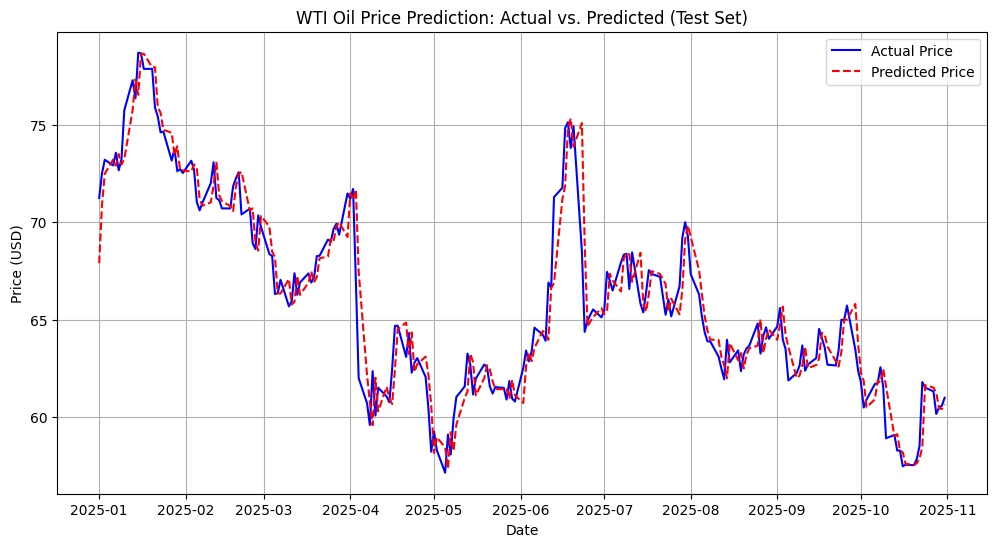


Final Test Metrics: RMSE = 1.3957, MAE = 1.0052


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Generate predictions for the test set
# The predict method uses the fitted SVR model to generate price forecasts
y_pred = svr_model.predict(X_test_reshaped)

# 2. Organize results into a DataFrame for analysis
# We use d_te (test dates), y_te (actual prices), and y_pred (forecasted prices)
results_df = pd.DataFrame({
    'Date': d_te,
    'Actual_Price': y_te,
    'Predicted_Price': y_pred
})

# 3. Display the first few rows of the prediction results
print("Test Set Prediction Samples:")
print(results_df.head())

# 4. Visualization: Plot Actual vs. Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(results_df['Date'], results_df['Actual_Price'], label='Actual Price', color='blue')
plt.plot(results_df['Date'], results_df['Predicted_Price'], label='Predicted Price', color='red', linestyle='--')
plt.title('WTI Oil Price Prediction: Actual vs. Predicted (Test Set)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# 5. Optional: Calculate specific error metrics for the test set
test_metrics = svr_model.evaluate(X_test_reshaped, y_te)
print(f"\nFinal Test Metrics: RMSE = {test_metrics['rmse']:.4f}, MAE = {test_metrics['mae']:.4f}")